In [27]:
import matplotlib.pyplot as plt
import os
import sys
sys.path.append('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/scripts')

sys.path.append('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/scripts/mge_classv2')
from mge_gen3 import MGEFitter
from astropy.io import fits
import numpy as np
import mgefit as mge
from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# Load kinematics results using PHOENIX templates

In [28]:
# the file is a csv with the format:
# X;Y;LOSV;LOSV_err;sigma;sigma_err;h3;h4
kin_table_antoine = Table.read("/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/IFU/antoine/M104_stellar_Kin.csv", format="csv", delimiter=";")

In [29]:
agn_sub = Table.read('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/ppxf_nirspec/phoenix_g235h_wavelength_lsf/g235h_agn_sub_phoenix_lsf_table_kinematics.csv',  format="csv", delimiter=";")

In [82]:
wicked = Table.read('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/ppxf_nirspec/antoine_wicked_powerbin_sn120_wavelength_lsf/sombrero_nirspec_1150_p1293_g235_wicked_phoenix_powerbin_lsf_sn120_kinematics.csv',  format="csv", delimiter=";")

In [83]:
agn_sub_sn = Table.read('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/ppxf_nirspec/agn_sub_powerbin_sn120_wavelength_lsf/g235h_agn_sub_phoenix_powerbin_lsf_sn120_kinematics_all.csv',  format="csv", delimiter=";")

In [101]:
kam_adaptive_trace = Table.read('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/ppxf_nirspec/adaptive_trace_step_kam_sn120_lsf/f170lp_g235h-f170lp_s3d_phoenix_powerbin_lsf_sn120_kinematics.csv',  format="csv", delimiter=";")

In [102]:
   
def plot_map(x, y, values, cmap='RdBu_r', cbar_label='Value',
              ax=None, show=True, vmin=None, vmax=None, cbar=True):
    # takes the xy and values and plots as an image with a colorbar
    # create a grid of x and y values
    xi = np.linspace(np.min(x), np.max(x), 100)
    yi = np.linspace(np.min(y), np.max(y), 100)
    xi, yi = np.meshgrid(xi, yi)
    # interpolate the values onto the grid
    zi = griddata((x, y), values, (xi, yi), method='cubic')
    # plot the image
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))
    im = ax.imshow(zi, extent=(np.min(x), np.max(x), np.min(y), np.max(y)),
                    origin='lower', cmap=cmap, vmin=vmin, vmax=vmax)
    if cbar:
        plt.colorbar(im, ax=ax, label=cbar_label, pad=0.01)
    ax.set_xlabel('X (arcsec)')
    ax.set_ylabel('Y (arcsec)')
    if show:
        plt.show()

def rotate(x, y, angle_deg):
    angle_rad = np.radians(angle_deg)
    x_rot = x * np.cos(angle_rad) - y * np.sin(angle_rad)
    y_rot = x * np.sin(angle_rad) + y * np.cos(angle_rad)
    return x_rot, y_rot


# MGE contour helper


In [103]:
def _mge_arrays_from_runner_or_csv(source=None, runner=None, csv_path=None,
                                   pixel_scale=None,
                                   total_col='total_counts',
                                   sigma_pix_col='sigma_pix',
                                   sigma_arcsec_col='sigma_arcsec',
                                   q_col='q_obs',
                                   surf_col='surf_counts_per_pix'):
    '''Return MGE peak, sigma_arcsec, q arrays from a runner or a CSV table.'''
    if source is not None:
        if runner is not None or csv_path is not None:
            raise ValueError('Pass either source, runner, or csv_path, not multiple inputs.')
        if isinstance(source, (str, os.PathLike)):
            csv_path = source
        else:
            runner = source

    if (runner is None) == (csv_path is None):
        raise ValueError('Pass exactly one MGE source: runner=... or csv_path=...')

    if runner is not None:
        fit_result = getattr(runner, 'fit_result', None)
        if fit_result is None:
            raise RuntimeError('runner.fit_result is empty. Run runner.run_fit() first, or pass csv_path=...')
        if pixel_scale is None:
            pixel_scale = getattr(runner, 'pixel_scale', None)
        if pixel_scale is None:
            raise ValueError('pixel_scale is required when it cannot be read from the runner.')
        total_counts, sigma_pix, q_obs = [np.asarray(v, dtype=float) for v in fit_result.sol[:3]]
        sigma_arcsec = sigma_pix * float(pixel_scale)
        peak = total_counts / (2.0 * np.pi * sigma_pix**2 * q_obs)
    else:
        if pixel_scale is None:
            pixel_scale = 0.031
        tab = Table.read(csv_path, format='csv')
        cols = set(tab.colnames)

        if total_col not in cols and 'total_flux' in cols:
            total_col = 'total_flux'
        if q_col not in cols and 'q' in cols:
            q_col = 'q'
        if sigma_pix_col not in cols and 'sigma' in cols:
            sigma_pix_col = 'sigma'

        if q_col not in cols:
            raise ValueError(f'CSV needs a {q_col!r} column.')
        q_obs = np.asarray(tab[q_col], dtype=float)

        sigma_pix = None
        sigma_arcsec = None
        if sigma_pix_col in cols:
            sigma_pix = np.asarray(tab[sigma_pix_col], dtype=float)
            sigma_arcsec = sigma_pix * float(pixel_scale)
        elif sigma_arcsec_col in cols:
            sigma_arcsec = np.asarray(tab[sigma_arcsec_col], dtype=float)
        else:
            raise ValueError(f'CSV needs {sigma_pix_col!r} or {sigma_arcsec_col!r}.')

        if surf_col in cols:
            peak = np.asarray(tab[surf_col], dtype=float)
        else:
            if total_col not in cols:
                raise ValueError(f'CSV needs {total_col!r}, {surf_col!r}, or total_flux.')
            total_counts = np.asarray(tab[total_col], dtype=float)
            sigma_for_norm = sigma_pix if sigma_pix is not None else sigma_arcsec
            peak = total_counts / (2.0 * np.pi * sigma_for_norm**2 * q_obs)

    good = np.isfinite(peak) & np.isfinite(sigma_arcsec) & np.isfinite(q_obs)
    good &= (peak > 0) & (sigma_arcsec > 0) & (q_obs > 0)
    if not np.any(good):
        raise ValueError('No valid positive MGE Gaussian components found.')
    return peak[good], sigma_arcsec[good], np.clip(q_obs[good], 1e-4, 1.0)


def _mge_equal_mag_levels(model, levels=None, nlevels=8, magstep=0.5, minlevel=None):
    if levels is not None:
        return np.unique(np.sort(np.asarray(levels, dtype=float)))

    valid = np.asarray(model, dtype=float)
    valid = valid[np.isfinite(valid) & (valid > 0)]
    if valid.size == 0:
        raise ValueError('MGE model is empty over the requested plotting range.')

    peak = np.nanmax(valid)
    floor = np.nanmin(valid)
    if minlevel is not None and np.isfinite(minlevel) and 0 < minlevel < peak:
        n = int(np.floor(np.log10(peak / minlevel) / (0.4 * magstep))) + 1
        n = max(n, 2)
    else:
        n = max(int(nlevels), 2)

    raw = peak * 10.0**(-0.4 * float(magstep) * np.arange(n))
    if minlevel is not None:
        raw = raw[raw >= minlevel]
    raw = raw[(raw > floor) & (raw < peak) & np.isfinite(raw)]

    if raw.size < 2:
        lo = minlevel if minlevel is not None and floor < minlevel < peak else np.nanpercentile(valid, 30)
        if not np.isfinite(lo) or lo <= floor or lo >= peak:
            lo = max(floor * 1.01, peak / 100.0)
        raw = np.geomspace(lo, peak * 0.999, max(int(nlevels), 2))

    return np.unique(np.sort(raw))


def overplot_mge_contours(ax, source=None, runner=None, csv_path=None,
                          pixel_scale=None, center=(0.0, 0.0), pa_deg=0.0,
                          xlim=None, ylim=None, grid_size=300,
                          levels=None, nlevels=8, magstep=0.5, minlevel=None,
                          color='k', linestyle='--', linewidth=1.2,
                          alpha=0.9, label='MGE contours', add_legend=False,
                          preserve_limits=True, zorder=5):
    '''Overplot model MGE contours on an existing kinematic-map axis.

    Coordinates are in the same arcsec frame as the target axis. The default
    pa_deg=0 aligns the MGE major axis with +x, which is convenient for the
    already-rotated X_rot/Y_rot kinematic maps in this notebook.

    Examples
    --------
    overplot_mge_contours(axs[1], runner=runner, color='k')
    overplot_mge_contours(axs[1], csv_path='Data/mge_NAGN_0deg_pa_positive_gauss/mge_solution.csv')
    '''
    peak, sigma_arcsec, q_obs = _mge_arrays_from_runner_or_csv(
        source=source,
        runner=runner,
        csv_path=csv_path,
        pixel_scale=pixel_scale,
    )

    old_xlim = ax.get_xlim()
    old_ylim = ax.get_ylim()
    if xlim is None:
        xlim = old_xlim
    if ylim is None:
        ylim = old_ylim

    xmin, xmax = sorted(xlim)
    ymin, ymax = sorted(ylim)
    x_grid = np.linspace(xmin, xmax, int(grid_size))
    y_grid = np.linspace(ymin, ymax, int(grid_size))
    x, y = np.meshgrid(x_grid, y_grid)

    dx = x - float(center[0])
    dy = y - float(center[1])
    pa = np.radians(pa_deg)
    x_major = dx * np.cos(pa) + dy * np.sin(pa)
    y_minor = -dx * np.sin(pa) + dy * np.cos(pa)

    model = np.zeros_like(x_major, dtype=float)
    for amp, sig, q in zip(peak, sigma_arcsec, q_obs):
        model += amp * np.exp(-0.5 * ((x_major / sig)**2 + (y_minor / (sig * q))**2))

    contour_levels = _mge_equal_mag_levels(
        model,
        levels=levels,
        nlevels=nlevels,
        magstep=magstep,
        minlevel=minlevel,
    )

    contours = ax.contour(
        x_grid,
        y_grid,
        model,
        levels=contour_levels,
        colors=color,
        linestyles=linestyle,
        linewidths=linewidth,
        alpha=alpha,
        zorder=zorder,
    )
    if label and getattr(contours, 'collections', None):
        contours.collections[0].set_label(label)
    if preserve_limits:
        ax.set_xlim(old_xlim)
        ax.set_ylim(old_ylim)
    if add_legend:
        ax.legend()
    return contours


# Rotate them


In [104]:
kin_table_antoine["X_rot"], kin_table_antoine["Y_rot"] = rotate(kin_table_antoine["X"],
                                                 kin_table_antoine["Y"], -18)

agn_sub['X_rot'], agn_sub['Y_rot'] = rotate(agn_sub['X'], agn_sub['Y'], -18)

wicked['X_rot'], wicked['Y_rot'] = rotate(wicked['X'], wicked['Y'], -18)

agn_sub_sn['X_rot'], agn_sub_sn['Y_rot'] = rotate(agn_sub_sn['X'], agn_sub_sn['Y'], -18)

kam_adaptive_trace['X_rot'], kam_adaptive_trace['Y_rot'] = rotate(kam_adaptive_trace['X'], kam_adaptive_trace['Y'], -18)

# Substract systemic velocity

In [105]:
def substract_systemic(tab):
    systemic = np.nanmedian(tab['LOSV'])
    tab['LOSV_sub'] = tab['LOSV'] - systemic
    return tab

In [106]:
kin_table_antoine = substract_systemic(kin_table_antoine)
wicked= substract_systemic(wicked)
agn_sub = substract_systemic(agn_sub)
agn_sub_sn = substract_systemic(agn_sub_sn)
kam_adaptive_trace = substract_systemic(kam_adaptive_trace)

# Plot comparison

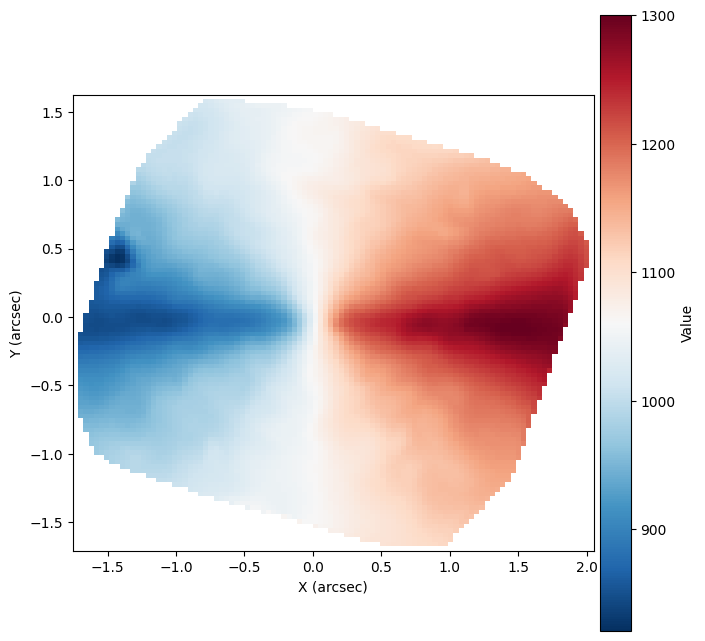

In [107]:
# plot VLOS maps
plot_map(kin_table_antoine['X_rot'], kin_table_antoine['Y_rot'], kin_table_antoine['LOSV'])


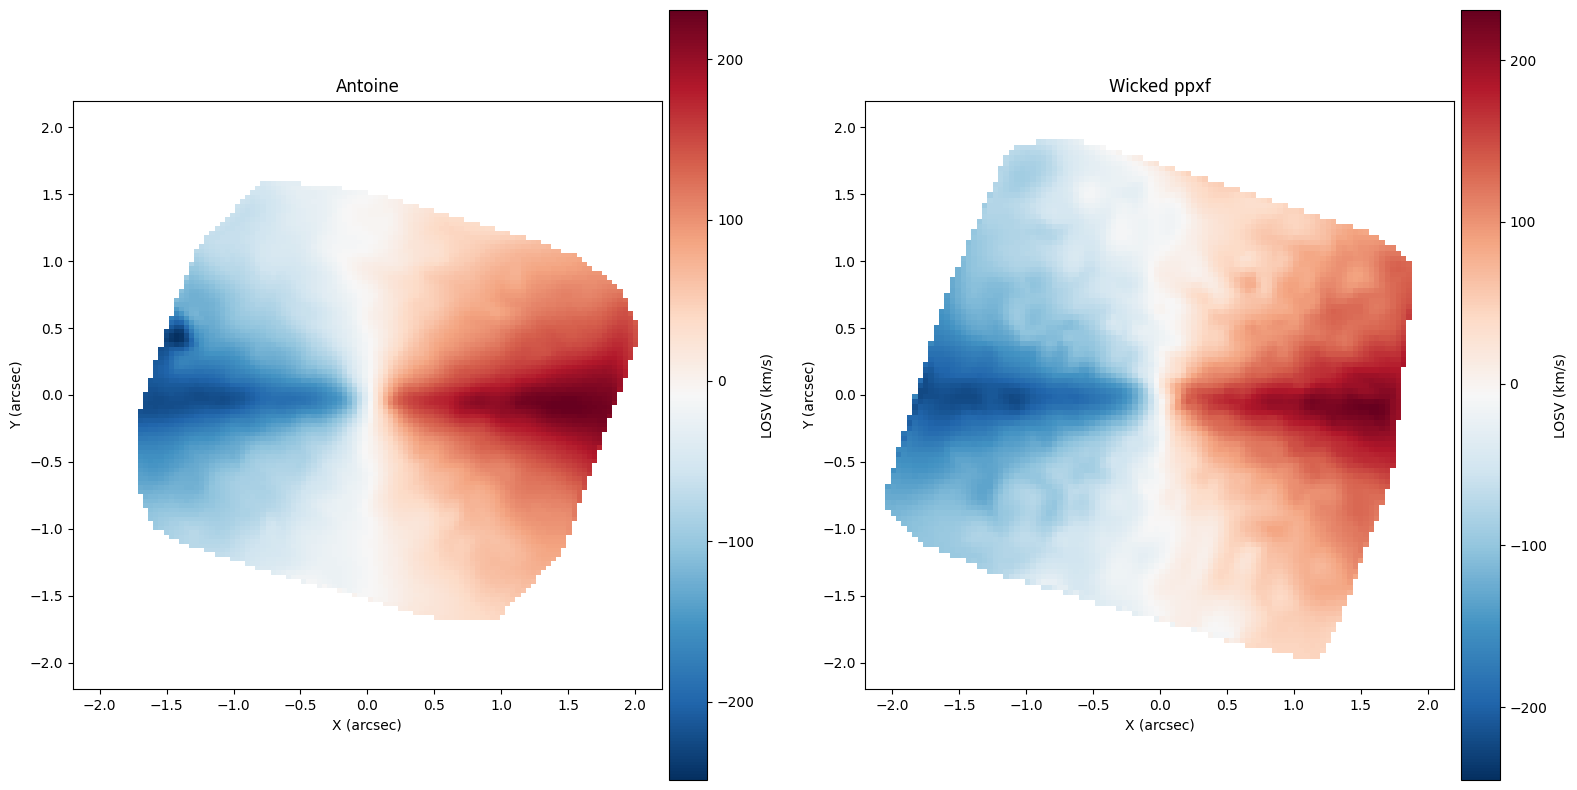

In [108]:
plotting_lim = 2.2
# plot a side to side view of the velocity maps from MUSE and NIRSpec
fig, axs = plt.subplots(1, 2, figsize=(16, 8))
plot_map(kin_table_antoine["X_rot"], kin_table_antoine["Y_rot"], kin_table_antoine["LOSV_sub"], cbar_label='LOSV (km/s)', ax=axs[0], show=False) 
axs[0].set_title("Antoine")
# mask out the values outside the plotting limits in the MUSE map
plot_map(wicked["X_rot"], wicked["Y_rot"], wicked["LOSV_sub"], cbar_label='LOSV (km/s)', ax=axs[1], show=False, 
         vmin=np.nanmin(kin_table_antoine["LOSV_sub"]), vmax=np.nanmax(kin_table_antoine["LOSV_sub"])) 
# restrict the x and y limits to be the same for both plots
axs[0].set_xlim(-plotting_lim, plotting_lim)
axs[1].set_xlim(-plotting_lim, plotting_lim)
axs[0].set_ylim(-plotting_lim, plotting_lim)
axs[1].set_ylim(-plotting_lim, plotting_lim)
axs[1].set_title("Wicked ppxf")
plt.tight_layout()
plt.show()

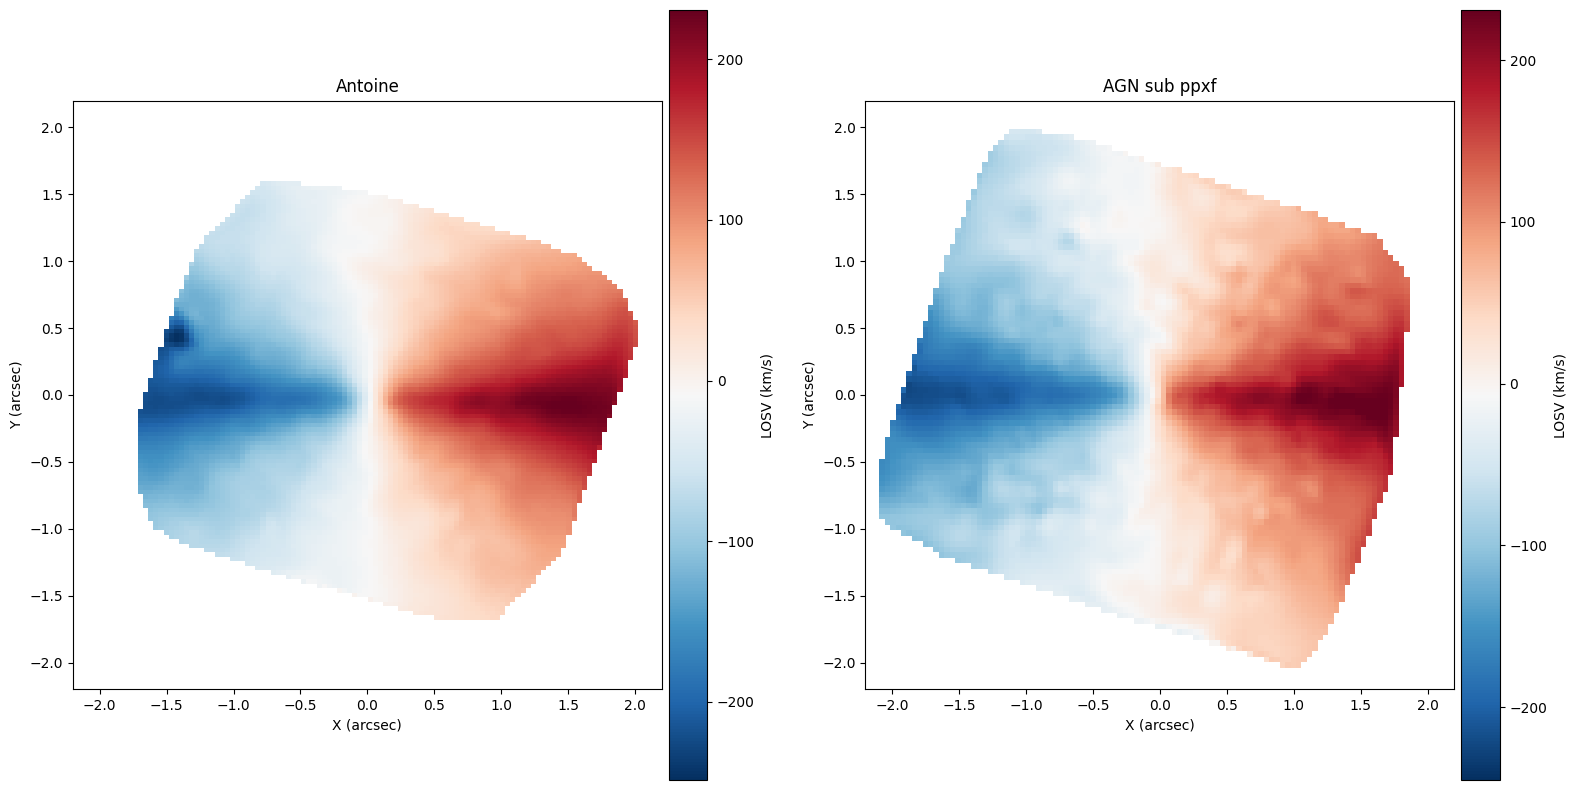

In [109]:
plotting_lim = 2.2
# plot a side to side view of the velocity maps from MUSE and NIRSpec
fig, axs = plt.subplots(1, 2, figsize=(16, 8))
plot_map(kin_table_antoine["X_rot"], kin_table_antoine["Y_rot"], kin_table_antoine["LOSV_sub"], cbar_label='LOSV (km/s)', ax=axs[0], show=False) 
axs[0].set_title("Antoine")
# mask out the values outside the plotting limits in the MUSE map
plot_map(agn_sub_sn["X_rot"], agn_sub_sn["Y_rot"], agn_sub_sn["LOSV_sub"], cbar_label='LOSV (km/s)', ax=axs[1], show=False, 
         vmin=np.nanmin(kin_table_antoine["LOSV_sub"]), vmax=np.nanmax(kin_table_antoine["LOSV_sub"])) 
# restrict the x and y limits to be the same for both plots
axs[0].set_xlim(-plotting_lim, plotting_lim)
axs[1].set_xlim(-plotting_lim, plotting_lim)
axs[0].set_ylim(-plotting_lim, plotting_lim)
axs[1].set_ylim(-plotting_lim, plotting_lim)
axs[1].set_title("AGN sub ppxf")
plt.tight_layout()
plt.show()

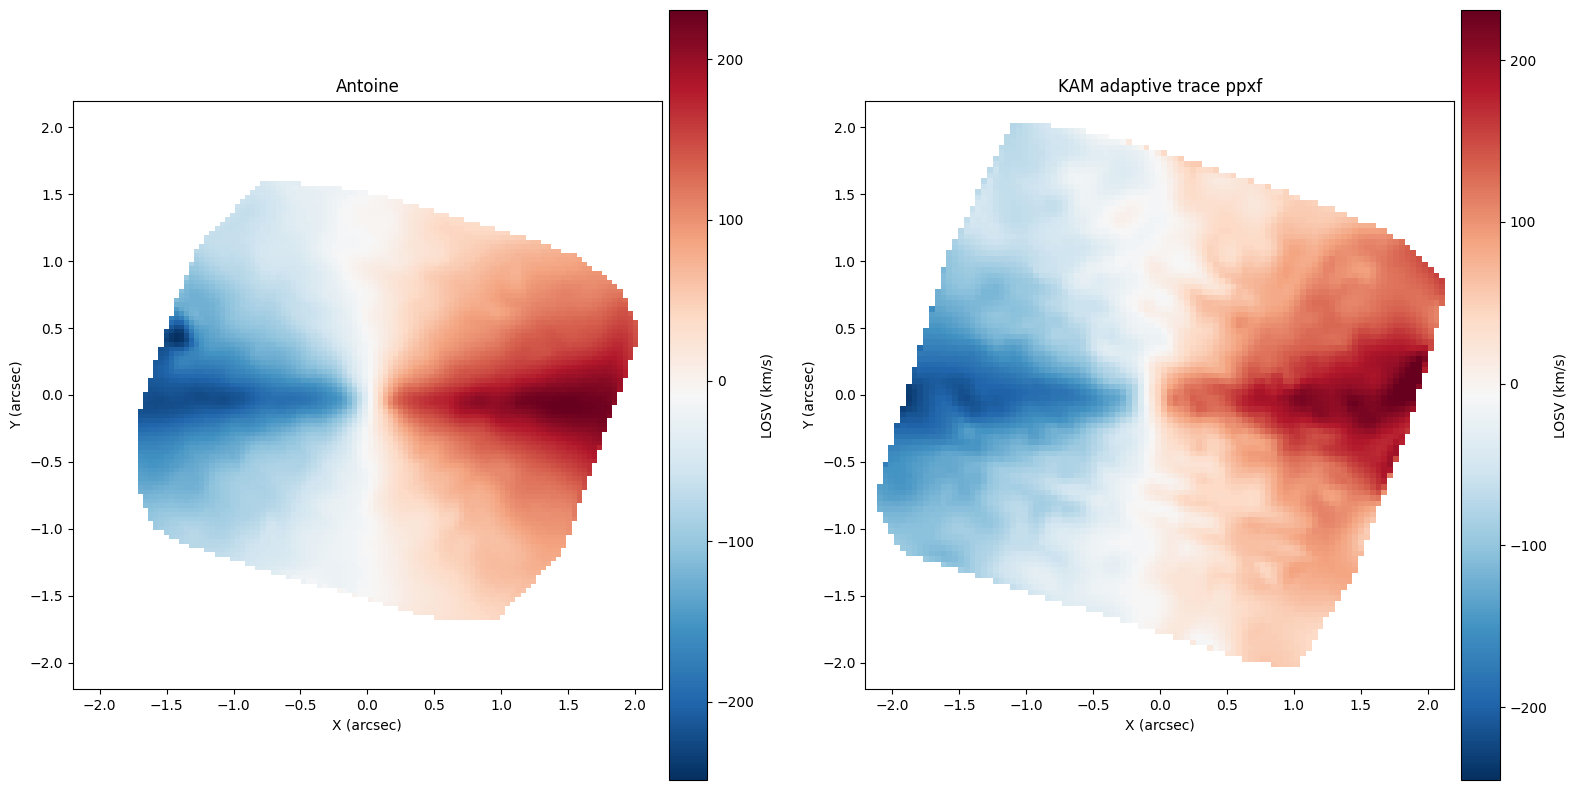

In [110]:
plotting_lim = 2.2
# plot a side to side view of the velocity maps from MUSE and NIRSpec
fig, axs = plt.subplots(1, 2, figsize=(16, 8))
plot_map(kin_table_antoine["X_rot"], kin_table_antoine["Y_rot"], kin_table_antoine["LOSV_sub"], cbar_label='LOSV (km/s)', ax=axs[0], show=False) 
axs[0].set_title("Antoine")
# mask out the values outside the plotting limits in the MUSE map
plot_map(kam_adaptive_trace["X_rot"], kam_adaptive_trace["Y_rot"], kam_adaptive_trace["LOSV_sub"], cbar_label='LOSV (km/s)', ax=axs[1], show=False, 
         vmin=np.nanmin(kin_table_antoine["LOSV_sub"]), vmax=np.nanmax(kin_table_antoine["LOSV_sub"])) 
# restrict the x and y limits to be the same for both plots
axs[0].set_xlim(-plotting_lim, plotting_lim)
axs[1].set_xlim(-plotting_lim, plotting_lim)
axs[0].set_ylim(-plotting_lim, plotting_lim)
axs[1].set_ylim(-plotting_lim, plotting_lim)
axs[1].set_title("KAM adaptive trace ppxf")
plt.tight_layout()
plt.show()

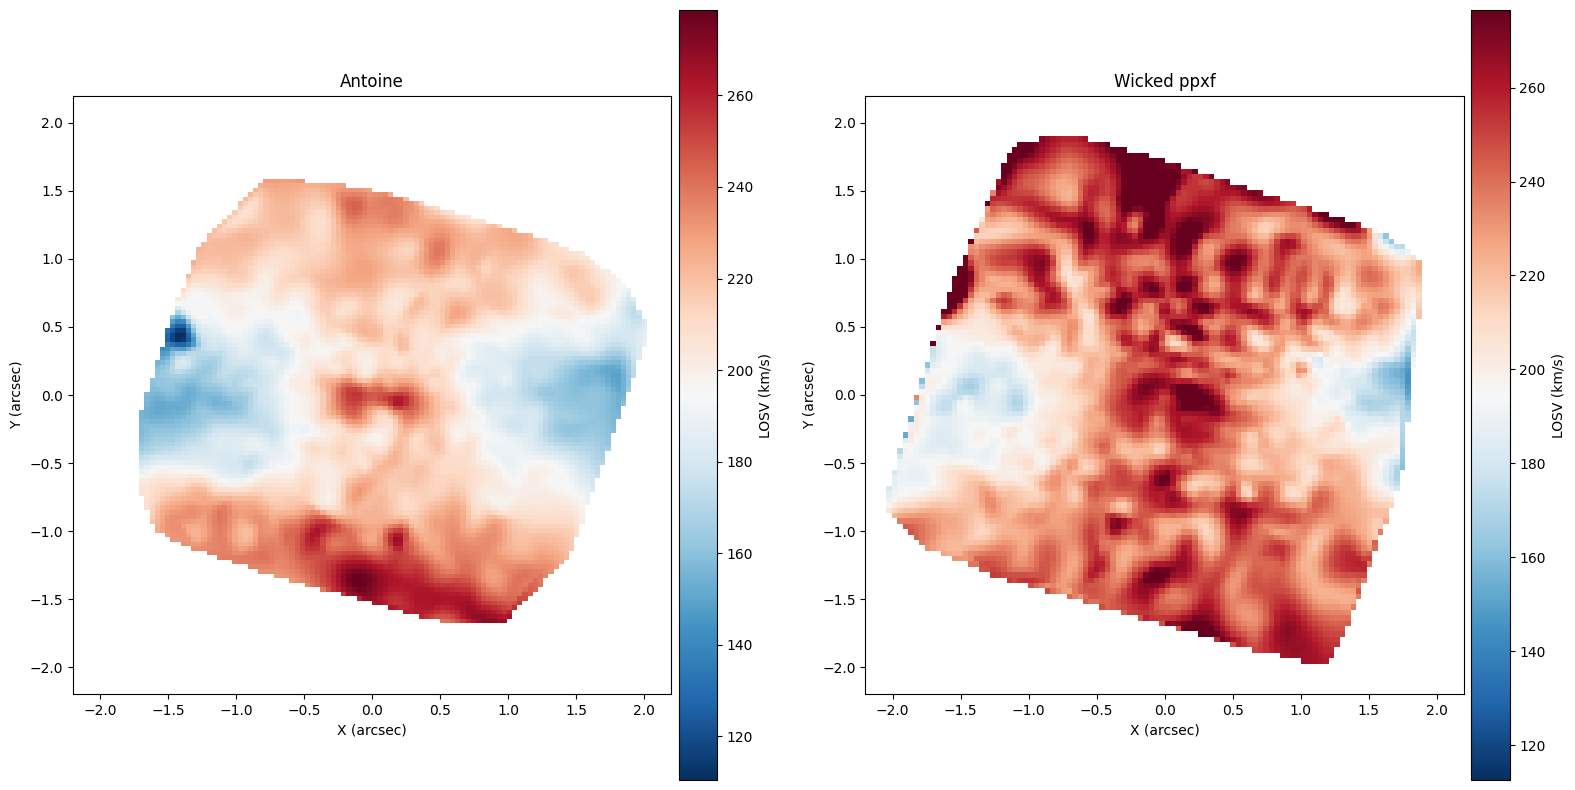

In [ ]:
plotting_lim = 2.2
# plot a side to side view of the velocity maps from MUSE and NIRSpec
fig, axs = plt.subplots(1, 2, figsize=(16, 8))
plot_map(kin_table_antoine["X_rot"], kin_table_antoine["Y_rot"], kin_table_antoine["sigma"], cbar_label='LOSV (km/s)', ax=axs[0], show=False) 
axs[0].set_title("Antoine")
# mask out the values outside the plotting limits in the MUSE map
plot_map(wicked["X_rot"], wicked["Y_rot"], wicked["sigma"], cbar_label='LOSV (km/s)', ax=axs[1], show=False, 
         vmin=np.nanmin(kin_table_antoine["sigma"]), vmax=np.nanmax(kin_table_antoine["sigma"])) 
# restrict the x and y limits to be the same for both plots
axs[0].set_xlim(-plotting_lim, plotting_lim)
axs[1].set_xlim(-plotting_lim, plotting_lim)
axs[0].set_ylim(-plotting_lim, plotting_lim)
axs[1].set_ylim(-plotting_lim, plotting_lim)
axs[1].set_title("Wicked ppxxf")
plt.tight_layout()
plt.show()

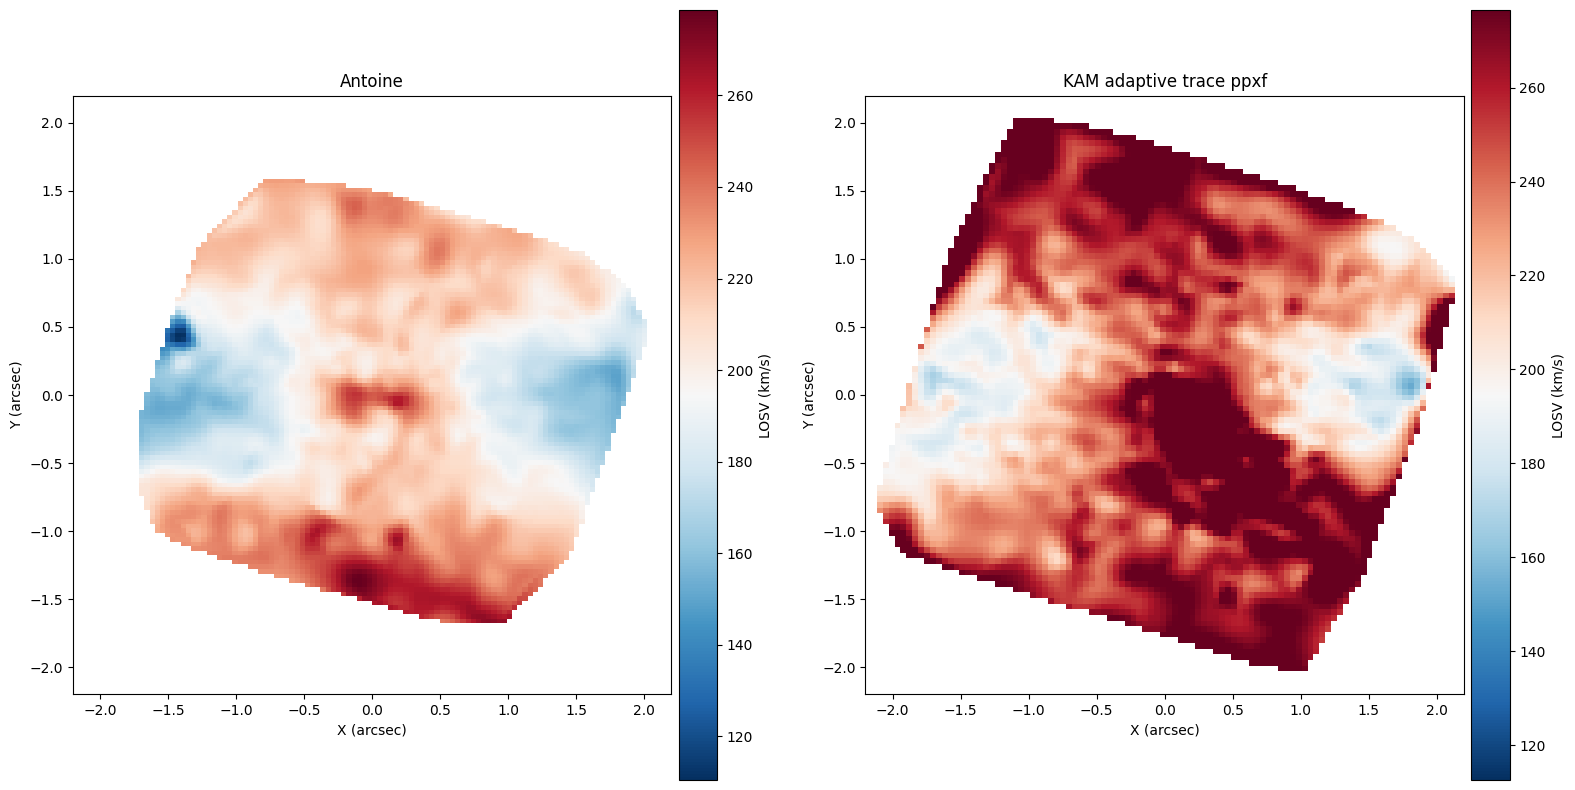

In [111]:
plotting_lim = 2.2
# plot a side to side view of the velocity maps from MUSE and NIRSpec
fig, axs = plt.subplots(1, 2, figsize=(16, 8))
plot_map(kin_table_antoine["X_rot"], kin_table_antoine["Y_rot"], kin_table_antoine["sigma"], cbar_label='LOSV (km/s)', ax=axs[0], show=False) 
axs[0].set_title("Antoine")
# mask out the values outside the plotting limits in the MUSE map
plot_map(kam_adaptive_trace["X_rot"], kam_adaptive_trace["Y_rot"], kam_adaptive_trace["sigma"], cbar_label='LOSV (km/s)', ax=axs[1], show=False, 
         vmin=np.nanmin(kin_table_antoine["sigma"]), vmax=np.nanmax(kin_table_antoine["sigma"])) 
# restrict the x and y limits to be the same for both plots
axs[0].set_xlim(-plotting_lim, plotting_lim)
axs[1].set_xlim(-plotting_lim, plotting_lim)
axs[0].set_ylim(-plotting_lim, plotting_lim)
axs[1].set_ylim(-plotting_lim, plotting_lim)
axs[1].set_title("KAM adaptive trace ppxf")
plt.tight_layout()
plt.show()

/var/folders/mw/xz5d5_4s6xz43rmhpz09kjrr0000gp/T/ipykernel_6010/2249826961.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


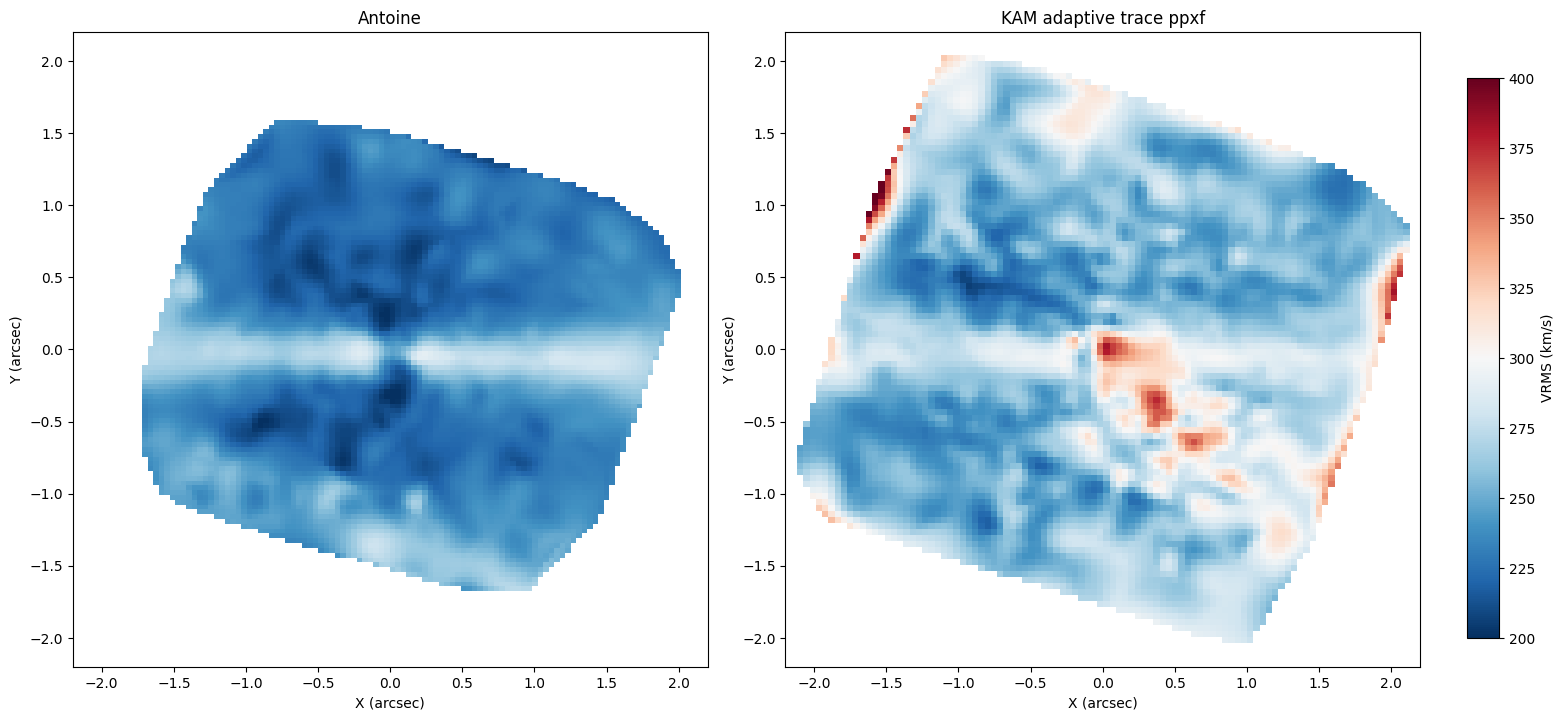

In [114]:
# plot the VRMS maps with the same colorbar limits to better compare the two
vmin = 200
vmax = 400
fig, axs = plt.subplots(1, 2, figsize=(16, 8))
plot_map(kin_table_antoine["X_rot"], kin_table_antoine["Y_rot"], np.sqrt(kin_table_antoine["LOSV_sub"]**2 + kin_table_antoine["sigma"]**2), 
cbar_label='VRMS (km/s)', ax=axs[0], show=False, vmin=vmin, vmax=vmax, cbar=False) 
# overplot 
axs[0].set_title("Antoine")

plot_map(kam_adaptive_trace["X_rot"], kam_adaptive_trace["Y_rot"], np.sqrt(kam_adaptive_trace["LOSV_sub"]**2 + kam_adaptive_trace["sigma"]**2), 
cbar_label='VRMS (km/s)', ax=axs[1], show=False, vmin=vmin, vmax=vmax, cbar=False) 
axs[1].set_title("KAM adaptive trace ppxf")
# restrict the x and y limits to be the same for both plots
axs[0].set_xlim(-plotting_lim, plotting_lim)
axs[1].set_xlim(-plotting_lim, plotting_lim)
axs[0].set_ylim(-plotting_lim, plotting_lim)
axs[1].set_ylim(-plotting_lim, plotting_lim)
# add a single colorbar for both plots
cbar_ax_resid = fig.add_axes([0.92, 0.15, 0.02, 0.7])
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=norm)
cbar = plt.colorbar(sm, cax=cbar_ax_resid, label='Vrms (km/s)',
 ax=cbar_ax_resid, orientation='vertical', fraction=0.02, pad=0.01)
cbar.set_label('VRMS (km/s)')
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

/var/folders/mw/xz5d5_4s6xz43rmhpz09kjrr0000gp/T/ipykernel_6010/1829722855.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


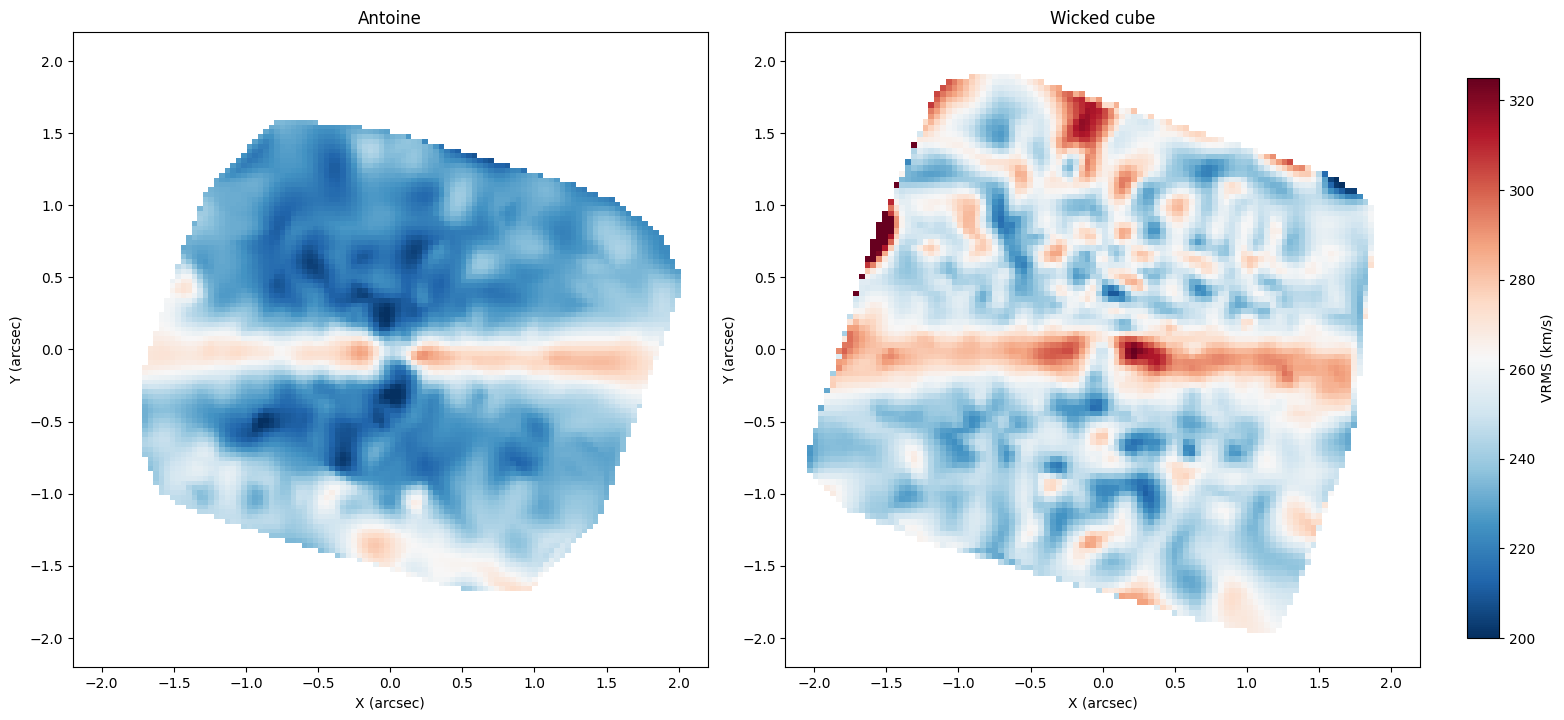

In [98]:
# plot the VRMS maps with the same colorbar limits to better compare the two
vmin = 200
vmax = 325
fig, axs = plt.subplots(1, 2, figsize=(16, 8))
plot_map(kin_table_antoine["X_rot"], kin_table_antoine["Y_rot"], np.sqrt(kin_table_antoine["LOSV_sub"]**2 + kin_table_antoine["sigma"]**2), 
cbar_label='VRMS (km/s)', ax=axs[0], show=False, vmin=vmin, vmax=vmax, cbar=False) 
# overplot 
axs[0].set_title("Antoine")

plot_map(wicked["X_rot"], wicked["Y_rot"], np.sqrt(wicked["LOSV_sub"]**2 + wicked["sigma"]**2), 
cbar_label='VRMS (km/s)', ax=axs[1], show=False, vmin=vmin, vmax=vmax, cbar=False) 
axs[1].set_title("Wicked cube")
# restrict the x and y limits to be the same for both plots
axs[0].set_xlim(-plotting_lim, plotting_lim)
axs[1].set_xlim(-plotting_lim, plotting_lim)
axs[0].set_ylim(-plotting_lim, plotting_lim)
axs[1].set_ylim(-plotting_lim, plotting_lim)
# add a single colorbar for both plots
cbar_ax_resid = fig.add_axes([0.92, 0.15, 0.02, 0.7])
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=norm)
cbar = plt.colorbar(sm, cax=cbar_ax_resid, label='Vrms (km/s)',
 ax=cbar_ax_resid, orientation='vertical', fraction=0.02, pad=0.01)
cbar.set_label('VRMS (km/s)')
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

/var/folders/mw/xz5d5_4s6xz43rmhpz09kjrr0000gp/T/ipykernel_6010/1791371832.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


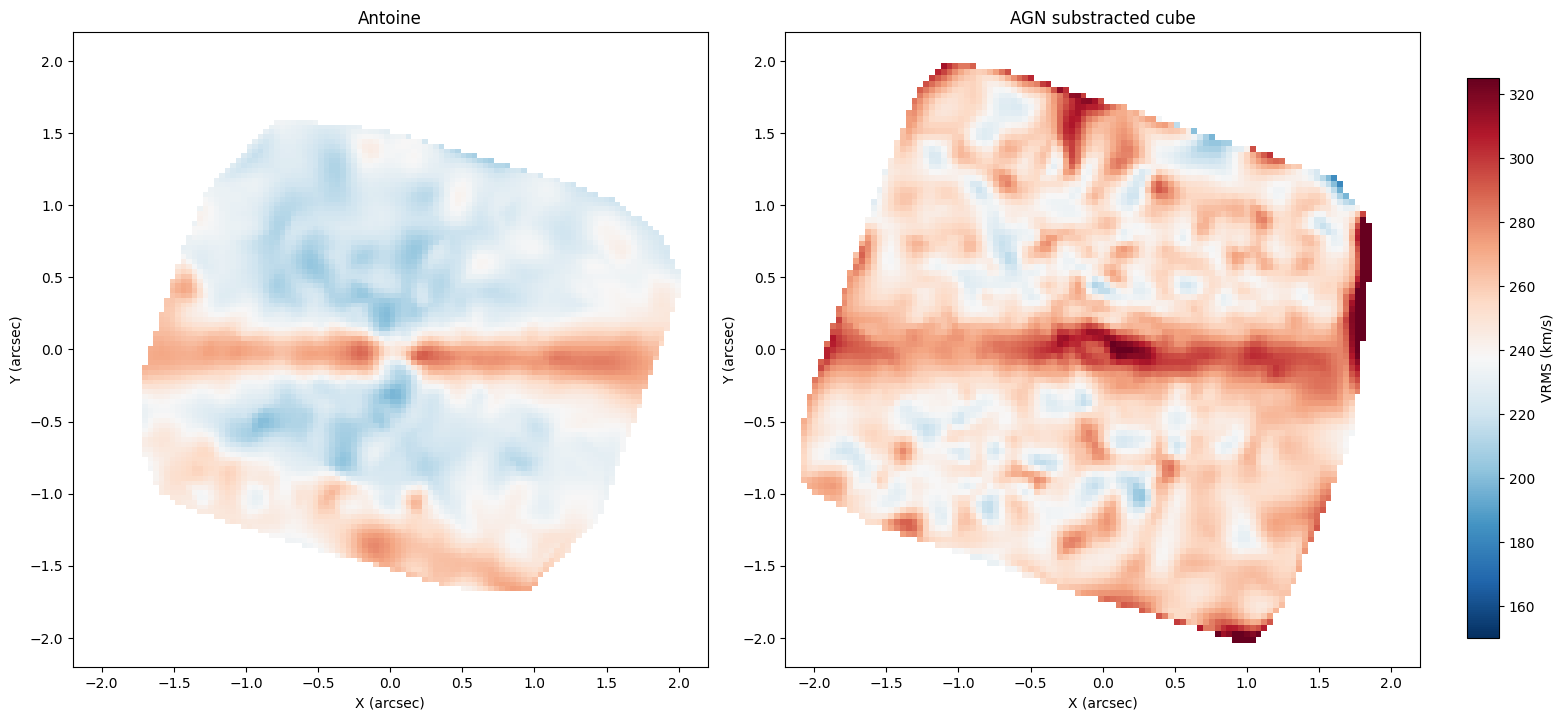

In [94]:
# same comparison with agn substracted cube
# plot the VRMS maps with the same colorbar limits to better compare the two
vmin = 150
vmax = 325
fig, axs = plt.subplots(1, 2, figsize=(16, 8))
plot_map(kin_table_antoine["X_rot"], kin_table_antoine["Y_rot"], np.sqrt(kin_table_antoine["LOSV_sub"]**2 + kin_table_antoine["sigma"]**2), 
cbar_label='VRMS (km/s)', ax=axs[0], show=False, vmin=vmin, vmax=vmax, cbar=False) 
axs[0].set_title("Antoine")

plot_map(agn_sub_sn["X_rot"], agn_sub_sn["Y_rot"], np.sqrt(agn_sub_sn["LOSV_sub"]**2 + agn_sub_sn["sigma"]**2), 
cbar_label='VRMS (km/s)', ax=axs[1], show=False, vmin=vmin, vmax=vmax, cbar=False) 
axs[1].set_title("AGN substracted cube")
# restrict the x and y limits to be the same for both plots
axs[0].set_xlim(-plotting_lim, plotting_lim)
axs[1].set_xlim(-plotting_lim, plotting_lim)
axs[0].set_ylim(-plotting_lim, plotting_lim)
axs[1].set_ylim(-plotting_lim, plotting_lim)
# add a single colorbar for both plots
cbar_ax_resid = fig.add_axes([0.92, 0.15, 0.02, 0.7])
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=norm)
cbar = plt.colorbar(sm, cax=cbar_ax_resid, label='Vrms (km/s)',
 ax=cbar_ax_resid, orientation='vertical', fraction=0.02, pad=0.01)
cbar.set_label('VRMS (km/s)')
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

/var/folders/mw/xz5d5_4s6xz43rmhpz09kjrr0000gp/T/ipykernel_6010/1272040936.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


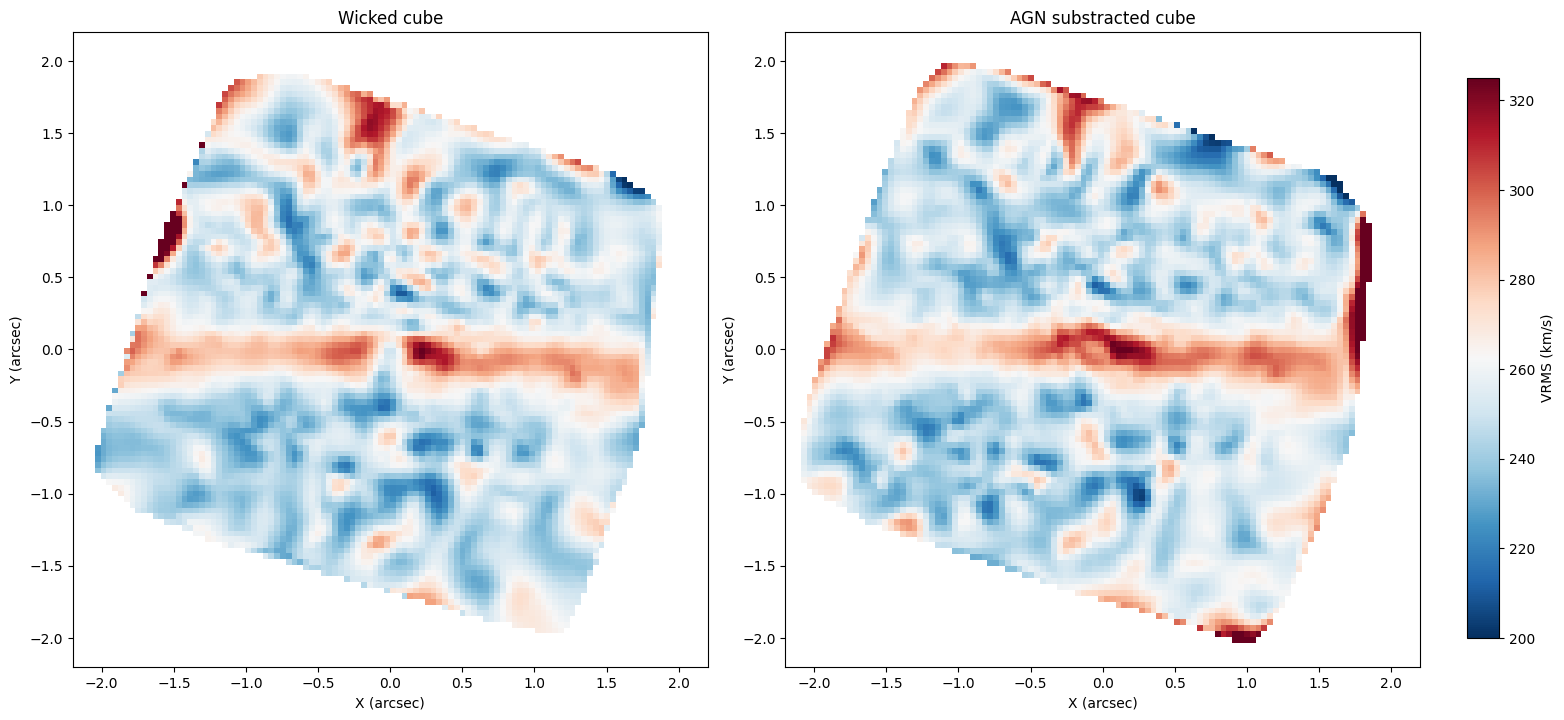

In [99]:
# same comparison with agn substracted cube
# plot the VRMS maps with the same colorbar limits to better compare the two
vmin = 200
vmax = 325
fig, axs = plt.subplots(1, 2, figsize=(16, 8))
plot_map(wicked["X_rot"], wicked["Y_rot"], np.sqrt(wicked["LOSV_sub"]**2 + wicked["sigma"]**2), 
cbar_label='VRMS (km/s)', ax=axs[0], show=False, vmin=vmin, vmax=vmax, cbar=False) 
axs[0].set_title("Wicked cube")

plot_map(agn_sub_sn["X_rot"], agn_sub_sn["Y_rot"], np.sqrt(agn_sub_sn["LOSV_sub"]**2 + agn_sub_sn["sigma"]**2), 
cbar_label='VRMS (km/s)', ax=axs[1], show=False, vmin=vmin, vmax=vmax, cbar=False) 
axs[1].set_title("AGN substracted cube")
# restrict the x and y limits to be the same for both plots
axs[0].set_xlim(-plotting_lim, plotting_lim)
axs[1].set_xlim(-plotting_lim, plotting_lim)
axs[0].set_ylim(-plotting_lim, plotting_lim)
axs[1].set_ylim(-plotting_lim, plotting_lim)
# add a single colorbar for both plots
cbar_ax_resid = fig.add_axes([0.92, 0.15, 0.02, 0.7])
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=norm)
cbar = plt.colorbar(sm, cax=cbar_ax_resid, label='Vrms (km/s)',
 ax=cbar_ax_resid, orientation='vertical', fraction=0.02, pad=0.01)
cbar.set_label('VRMS (km/s)')
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

# Over plot mge contours

In [41]:
# load mge and plot isophotes
img_f200 = fits.open(
    '/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/IFU/photometry/f200w_ifu_coadd_masked.fits'
)[0].data

dust_mask = fits.open(
    '/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/dust_mask/f200_mask_1.fits'
)[0].data

nan_mask = np.isnan(img_f200)
if np.any(nan_mask):
    print(f"Found {np.sum(nan_mask)} NaN pixels in the image. Replacing with 0 and adding to dust mask.")
    img_f200[nan_mask] = 0.0
    #dust_mask = dust_mask | nan_mask
    dust_mask[nan_mask] = 0

checkplot_dir = "/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/mge_test_nosky_0deg_pa_positive_gauss"


runner = MGEFitter(
    img_f200,
    dust_mask,
    pixel_scale=0.031,
    subtract_sky=False,
    linear=False,
    ngauss=30,
    plot=True,
    checkplot_dir=checkplot_dir,
    cache_dir=checkplot_dir,
    prefix="sombrero_f200",
    contour_half_size_arcsec=10,
    contour_oversample=1,
    n_sectors=19,
)

Found 79853441 NaN pixels in the image. Replacing with 0 and adding to dust mask.


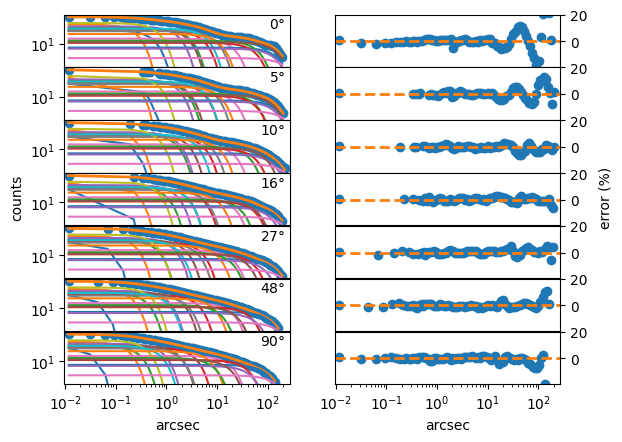

In [42]:
runner.run_fit().plot()
plt.pause(1)


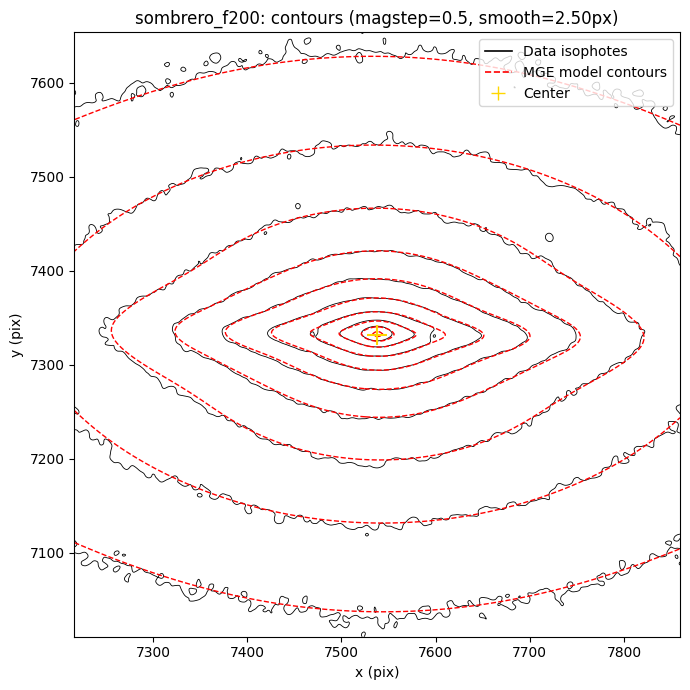

In [43]:
runner._plot_fit_contours(show=True, smoothing=2.5, magstep=0.5, minlevel=10)

/var/folders/mw/xz5d5_4s6xz43rmhpz09kjrr0000gp/T/ipykernel_6010/2818786298.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


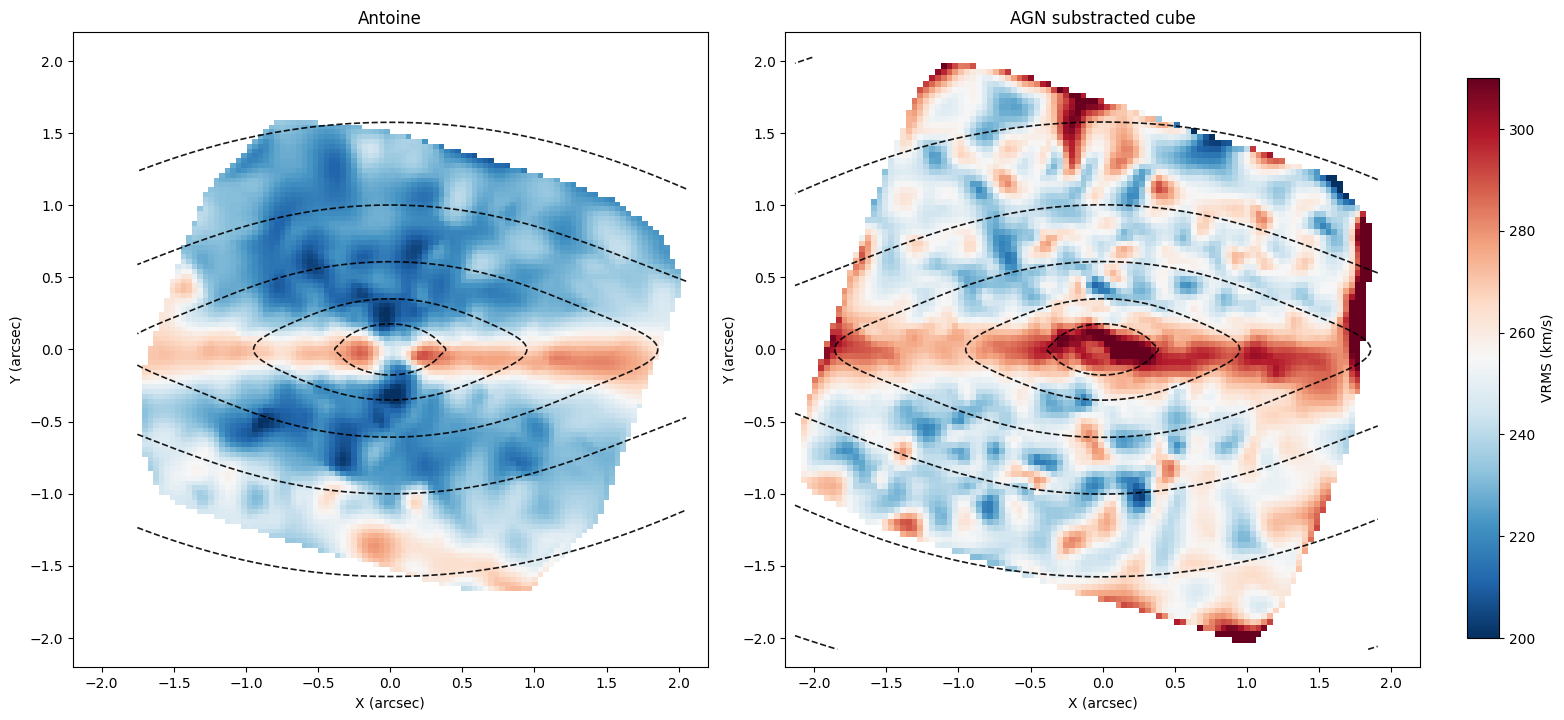

In [95]:
# same comparison with agn substracted cube
# plot the VRMS maps with the same colorbar limits to better compare the two
vmin = 200
vmax = 310
fig, axs = plt.subplots(1, 2, figsize=(16, 8))
plot_map(kin_table_antoine["X_rot"], kin_table_antoine["Y_rot"], np.sqrt(kin_table_antoine["LOSV_sub"]**2 + kin_table_antoine["sigma"]**2), 
cbar_label='VRMS (km/s)', ax=axs[0], show=False, vmin=vmin, vmax=vmax, cbar=False) 
# overplot contours
overplot_mge_contours(axs[0], runner=runner, color='k')

axs[0].set_title("Antoine")

plot_map(agn_sub_sn["X_rot"], agn_sub_sn["Y_rot"], np.sqrt(agn_sub_sn["LOSV_sub"]**2 + agn_sub_sn["sigma"]**2), 
cbar_label='VRMS (km/s)', ax=axs[1], show=False, vmin=vmin, vmax=vmax, cbar=False) 
overplot_mge_contours(axs[1], runner=runner, color='k')
axs[1].set_title("AGN substracted cube")
# restrict the x and y limits to be the same for both plots
axs[0].set_xlim(-plotting_lim, plotting_lim)
axs[1].set_xlim(-plotting_lim, plotting_lim)
axs[0].set_ylim(-plotting_lim, plotting_lim)
axs[1].set_ylim(-plotting_lim, plotting_lim)
# add a single colorbar for both plots
cbar_ax_resid = fig.add_axes([0.92, 0.15, 0.02, 0.7])
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=norm)
cbar = plt.colorbar(sm, cax=cbar_ax_resid, label='Vrms (km/s)',
 ax=cbar_ax_resid, orientation='vertical', fraction=0.02, pad=0.01)
cbar.set_label('VRMS (km/s)')
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

/var/folders/mw/xz5d5_4s6xz43rmhpz09kjrr0000gp/T/ipykernel_6010/2881881352.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


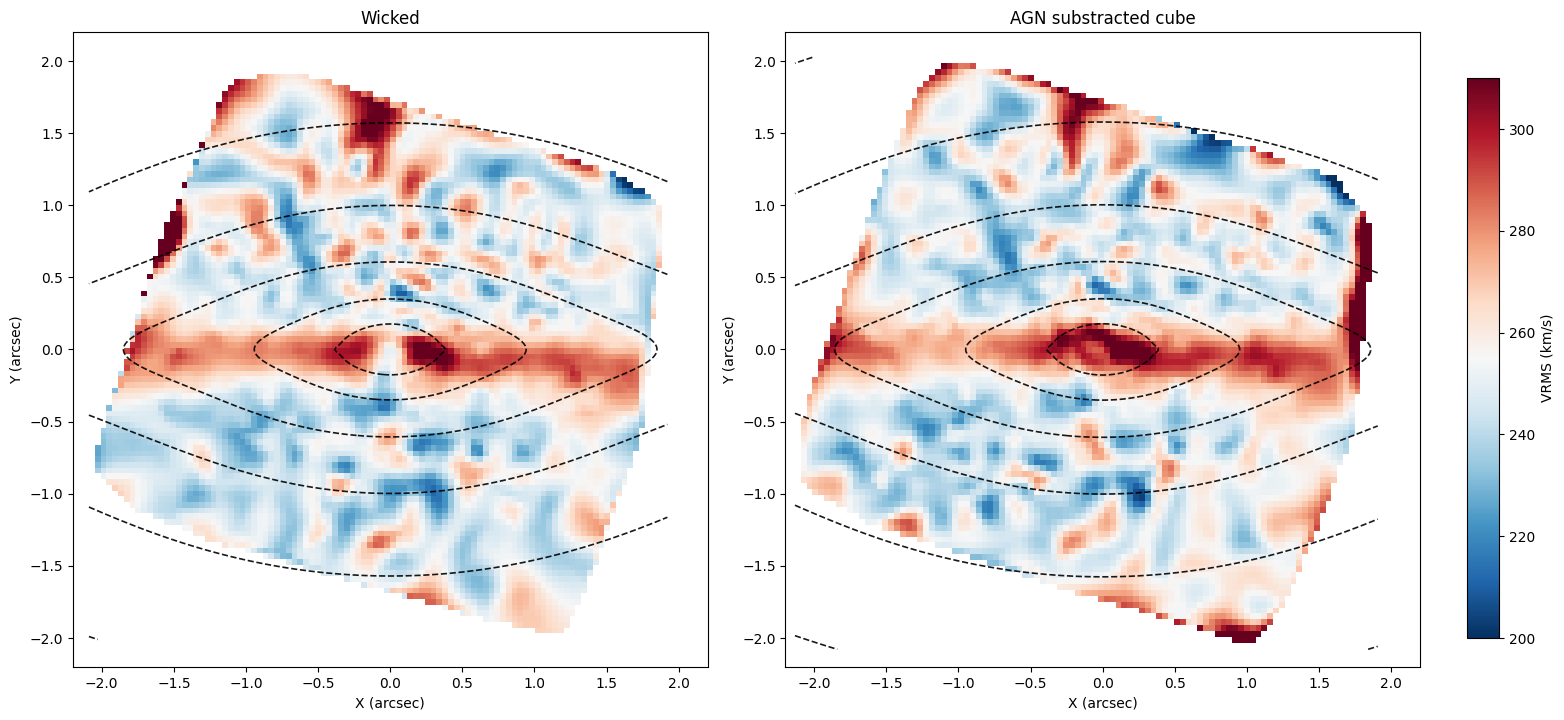

In [96]:
# same comparison with agn substracted cube
# plot the VRMS maps with the same colorbar limits to better compare the two
vmin = 200
vmax = 310
fig, axs = plt.subplots(1, 2, figsize=(16, 8))
plot_map(wicked["X_rot"], wicked["Y_rot"], np.sqrt(wicked["LOSV_sub"]**2 + wicked["sigma"]**2), 
cbar_label='VRMS (km/s)', ax=axs[0], show=False, vmin=vmin, vmax=vmax, cbar=False) 
# overplot contours
overplot_mge_contours(axs[0], runner=runner, color='k')

axs[0].set_title("Wicked")

plot_map(agn_sub_sn["X_rot"], agn_sub_sn["Y_rot"], np.sqrt(agn_sub_sn["LOSV_sub"]**2 + agn_sub_sn["sigma"]**2), 
cbar_label='VRMS (km/s)', ax=axs[1], show=False, vmin=vmin, vmax=vmax, cbar=False) 
overplot_mge_contours(axs[1], runner=runner, color='k')
axs[1].set_title("AGN substracted cube")
# restrict the x and y limits to be the same for both plots
axs[0].set_xlim(-plotting_lim, plotting_lim)
axs[1].set_xlim(-plotting_lim, plotting_lim)
axs[0].set_ylim(-plotting_lim, plotting_lim)
axs[1].set_ylim(-plotting_lim, plotting_lim)
# add a single colorbar for both plots
cbar_ax_resid = fig.add_axes([0.92, 0.15, 0.02, 0.7])
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=norm)
cbar = plt.colorbar(sm, cax=cbar_ax_resid, label='Vrms (km/s)',
 ax=cbar_ax_resid, orientation='vertical', fraction=0.02, pad=0.01)
cbar.set_label('VRMS (km/s)')
plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()